In [44]:
!git clone https://github.com/ajurcik/MLPrague-2026-test.git
!pip install ./MLPrague-2026-test

!pip install -r MLPrague-2026-test/requirements.txt

# Anomaly Detection on Graphs — Hands-on Workshop

In this notebook you will apply several anomaly detection methods to the **YelpChi** fraud-review dataset.  
The dataset contains Yelp reviews with hand-crafted features and a binary `spam` label. Reviews are connected through edges, forming a graph.

**Models we will train & compare:**
1. **Isolation Forest** — a classical tree-based anomaly detector
2. **Graph Auto Encoder** — mix of GNN and autoencoder
3. **Heterogeneous Graph Auto Encoder** - GAE version with heterogeneous edges

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import classification_report
from sklearn.preprocessing import minmax_scale

from ml_prague_2026.evaluation import compare_models, evaluate_model

from pygod.detector import DOMINANT, GADNR

import torch
import torch.nn as tnn
import torch_geometric.nn as nn
import torch_geometric.utils as utils
import torch.nn.functional as F
from torch_geometric.utils import add_self_loops
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.seed import seed_everything
from torch_geometric.utils import degree as pyg_degree
from sklearn.preprocessing import StandardScaler


seed_everything(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
YELP_CHI_PATH = 'MLPrague-2026-test/data/yelpchi.parquet'

YELP_CHI_EDGE_RSR_PATH = 'MLPrague-2026-test/data/yelpchi_rsr.npy'
YELP_CHI_EDGE_RTR_PATH = 'MLPrague-2026-test/data/yelpchi_rtr.npy'
YELP_CHI_EDGE_RUR_PATH = 'MLPrague-2026-test/data/yelpchi_rur.npy'

## 1. Data Loading

We start by loading the preprocessed YelpChi dataset (reviews with features) and the three edge lists that connect reviews sharing the same restaurant, timestamp, or user.

In [5]:
yelp_chi = pd.read_parquet(YELP_CHI_PATH)
yelp_chi.head(2)

,date,review_id,user_id,product_id,spam,useful,funny,cool,stars,review,...,f_u_etg,f_u_rl,f_p_mnr,f_p_pr,f_p_nr,f_p_avgrd,f_p_wrd,f_p_erd,f_p_etg,f_p_rl
0,2011-06-08,MyNjnxzZVTPq,IFTr6_6NI4CgCVavIL9k5g,tQfLGoolUMu2J0igcWcoZg,0,28,11,18,5,Let me begin by saying that there are two kind...,...,0.94806,0.867772,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512
1,2011-08-30,BdD7fsPqHQL73hwENEDT-Q,c_-hF15XgNhlyy_TqzmdaA,tQfLGoolUMu2J0igcWcoZg,0,4,3,0,3,The only place inside the Loop that you can st...,...,0.94806,0.826367,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512


In [6]:
edges = np.concatenate((
    np.load(YELP_CHI_EDGE_RSR_PATH, allow_pickle=True),
    np.load(YELP_CHI_EDGE_RTR_PATH, allow_pickle=True),
    np.load(YELP_CHI_EDGE_RUR_PATH, allow_pickle=True),
), axis=0)

In [7]:
# Load train/test split from file (to ensure consistency with supervised notebook)
data_split = np.load('MLPrague-2026-test/data/yelpchi_split.npz')
train_idx = np.concatenate([data_split['train'], data_split['val']])
test_idx = data_split['test']

## 2. Isolation Forest

[Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) is a tree-based anomaly detector that works on tabular features **without** graph structure.  
It isolates anomalies by randomly partitioning features — anomalies require fewer splits, resulting in shorter average path lengths.

In [8]:
def prepare_yelp_chi_tabular_data(yelp_chi, train_split, test_split, add_degree_feature: bool = True):
    """Prepare train/test features and labels for Yelp-Chi in tabular form.

    Args:
        yelp_chi: DataFrame with node features (f_*) and 'spam' label.
        add_degree_feature: If True, append degree features from RUR/RSR/RTR edges.

    Returns:
        X_train, X_test, y_train, y_test
    """
    # Prepare features and labels
    feature_cols = [c for c in yelp_chi.columns if c.startswith('f_')]
    X = yelp_chi[feature_cols].values
    y_true = yelp_chi['spam'].values

    if add_degree_feature:
        def undirected_degree(edge_index: torch.Tensor, num_nodes: int) -> np.ndarray:
            """Sum degrees from both directions to handle undirected edges."""
            return (
                pyg_degree(edge_index[0], num_nodes=num_nodes)
                + pyg_degree(edge_index[1], num_nodes=num_nodes)
            ).numpy()

        n_nodes = len(yelp_chi)
        edge_paths = {
            "rur": YELP_CHI_EDGE_RUR_PATH,
            "rsr": YELP_CHI_EDGE_RSR_PATH,
            "rtr": YELP_CHI_EDGE_RTR_PATH,
        }

        degree_features = []
        for path in edge_paths.values():
            edgs = torch.tensor(np.load(path, allow_pickle=True).T, dtype=torch.long)
            degree_features.append(undirected_degree(edgs, n_nodes)[:, None])

        X = np.concatenate([X, *degree_features], axis=1)

    # Load train/test split from file (to ensure consistency with supervised notebook)
    data_split = np.load('MLPrague-2026-test/data/yelpchi_split.npz')
    train_idx = np.concatenate([data_split['train'], data_split['val']])
    test_idx = data_split['test']

    X_train, X_test = X[train_split], X[test_split]
    y_train, y_test = y_true[train_split], y_true[test_split]

    return X_train, X_test, y_train, y_test

In [9]:
X_train, X_test, y_train, y_test = prepare_yelp_chi_tabular_data(yelp_chi, train_idx, test_idx, add_degree_feature=False)

We use the known **contamination rate** (fraction of spam) so the model threshold matches the true anomaly ratio.

In [10]:
# Contamination approximates the fraction of anomalies (spam) in the dataset
contamination = y_train.mean()
print(f'Contamination (proportion of anomalies): {contamination:.4f}')

Contamination (proportion of anomalies): 0.1453


### TASK 2.A: Experiment with contamination

In [11]:
# TASK 2.A: experiment with the contamination parameter
# - Try different values for contamination (e.g., 0.1, 0.2...)
# - Observe how it affects the recall and precision of the model on anomaly class

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)

iso_forest.fit(X_train)

IsolationForest(contamination=np.float64(0.14531309504379522), n_estimators=200,
                n_jobs=-1, random_state=42)

In [12]:
# IsolationForest returns -1 for anomalies, 1 for normal
y_pred_test = (iso_forest.predict(X_test) == -1).astype(int)

# Compute anomaly scores — negate score_samples so that higher = more anomalous
y_scores_test = -iso_forest.score_samples(X_test)
y_scores_test

array([0.55604014, 0.492651  , 0.50384849, ..., 0.47248961, 0.49113168,
       0.5364104 ])

In [13]:
# Sklearn classification report
print(classification_report(y_test, y_pred_test))

# Evaluate
isolation_forest_results = evaluate_model('isolation_forest', y_test, y_pred_test, y_scores_test)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7857
           1       0.30      0.30      0.30      1335

    accuracy                           0.79      9192
   macro avg       0.59      0.59      0.59      9192
weighted avg       0.80      0.79      0.80      9192



,Precision,Recall,AUPRC,Rec@K
0,0.589,0.591,0.267,0.302


### Isolation forest with degree feature
Let's try adding the number of connected neighbors as a graph feature.

In [14]:
X_train_graph, X_test_graph, y_train_graph, y_test_graph = prepare_yelp_chi_tabular_data(yelp_chi, train_idx, test_idx, add_degree_feature=True)

In [15]:
iso_forest_graph = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)

iso_forest_graph.fit(X_train_graph)

IsolationForest(contamination=np.float64(0.14531309504379522), n_estimators=200,
                n_jobs=-1, random_state=42)

In [16]:
# IsolationForest returns -1 for anomalies, 1 for normal
y_pred_test_graph = (iso_forest_graph.predict(X_test_graph) == -1).astype(int)

# Compute anomaly scores — negate score_samples so that higher = more anomalous
y_scores_test_graph = -iso_forest_graph.score_samples(X_test_graph)
y_scores_test_graph

array([0.55669488, 0.49751465, 0.50879919, ..., 0.46719504, 0.49229824,
       0.5341797 ])

In [17]:
# Evaluate
isolation_forest_graph_results = evaluate_model('isolation_forest_graph', y_test_graph, y_pred_test_graph, y_scores_test_graph)

,Precision,Recall,AUPRC,Rec@K
0,0.569,0.572,0.233,0.27


## 3. Graph auto encoder

GAE is autoencoder that uses a graph neural network as an encoder that learns node representations that reconstruct the original node features. Nodes with high reconstruction error (i.e., those the model fails to reconstruct well) are flagged as anomalies.

<img src="https://raw.githubusercontent.com/ajurcik/MLPrague-2026-test/refs/heads/master/presentation/images/gae.png" width="600">

We use the custom Pytorch Geometric implementation.

#### Building the PyTorch Geometric Graph

To use GNN-based detectors we need a `torch_geometric.Data` object that bundles:
- **`x`** — node feature matrix of shape `(num_nodes, num_features)`
- **`edge_index`** — edge list as a `(2, num_edges)` tensor with contiguous node indices
- **`y`** — ground-truth labels (used only for evaluation, not for training)

In [18]:
# Create edge index tensor
edge_index = torch.tensor(edges, dtype=torch.long)
if edge_index.shape[0] != 2:
    edge_index = edge_index.t()
edge_index = edge_index.contiguous()

# Add undirected edges (since the graph is undirected)
edge_index = utils.to_undirected(edge_index)

# Extract node features — select all columns that start with 'f_'
feature_cols = [c for c in yelp_chi.columns if c.startswith('f_')]
x = torch.tensor(yelp_chi[feature_cols].values, dtype=torch.float)

# Extract labels from the 'spam' column
y = torch.tensor(yelp_chi['spam'].values, dtype=torch.long)

# Create the PyTorch Geometric Data object with x, edge_index, and y
pytorch_data = Data(x=x, edge_index=edge_index, y=y)
pytorch_data = pytorch_data.to(device)

pytorch_data

Data(x=[45954, 30], edge_index=[2, 7693958], y=[45954])

In [19]:
# Apply train/test split to the PyG data object via masks
pytorch_data.train_mask = torch.zeros(pytorch_data.num_nodes, dtype=torch.bool)
pytorch_data.test_mask = torch.zeros(pytorch_data.num_nodes, dtype=torch.bool)
pytorch_data.train_mask[train_idx] = True
pytorch_data.test_mask[test_idx] = True
pytorch_data

Data(x=[45954, 30], edge_index=[2, 7693958], y=[45954], train_mask=[45954], test_mask=[45954])

In [20]:
pytorch_data

Data(x=[45954, 30], edge_index=[2, 7693958], y=[45954], train_mask=[45954], test_mask=[45954])

### Graph Auto Encoder baseline
Train custom GAE without any data preprocessing.

In [21]:
def mask_features(x, p_mask=0.3, mask_value=-1.0):
    """Returns corrupted x and a boolean mask of which positions were masked."""
    mask = torch.rand_like(x) < p_mask
    x_masked = x.clone()
    x_masked[mask] = mask_value
    return x_masked, mask

In [22]:
from torch_geometric.nn import GCNConv, SAGEConv


class GCNEncoder(tnn.Module):
    """Multi-layer GCN encoder that produces latent node embeddings."""

    def __init__(self, in_channels, hidden_channels, latent_channels, num_layers=2, dropout=0.3):
        super().__init__()
        self.convs = tnn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, latent_channels))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.leaky_relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x


class FeatureDecoder(tnn.Module):
    """MLP decoder that reconstructs node features from latent embeddings."""

    def __init__(self, latent_channels, hidden_channels, out_channels):
        super().__init__()
        self.fc1 = tnn.Linear(latent_channels, hidden_channels)
        self.fc2 = tnn.Linear(hidden_channels, out_channels)

    def forward(self, z):
        z = F.leaky_relu(self.fc1(z))
        return self.fc2(z)


class CustomGAE(tnn.Module):
    def __init__(self, in_channels, hidden_channels, latent_channels, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden_channels, latent_channels, num_layers, dropout)
        self.decoder = FeatureDecoder(latent_channels, hidden_channels, in_channels)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.decoder(z)
        return x_hat

In [23]:
# Instantiate and train the Custom GAE
in_channels = pytorch_data.x.size(1)
custom_gae = CustomGAE(
    in_channels=in_channels,
    hidden_channels=64,
    latent_channels=32,
    num_layers=1,
    dropout=0.3,
).to(device)

optimizer = torch.optim.Adam(custom_gae.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 200

custom_gae.train()

# Training loop:
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    x_masked, mask = mask_features(pytorch_data.x, p_mask=0.3)
    x_hat = custom_gae(x_masked, pytorch_data.edge_index)

    node_mask = pytorch_data.to(device).train_mask.unsqueeze(1) & mask
    mse = F.mse_loss(x_hat[node_mask], pytorch_data.x[node_mask])

    mse.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {mse.item():.6f}")

Epoch   1/200 | Train Loss: 0.512748
Epoch  10/200 | Train Loss: 0.423085
Epoch  20/200 | Train Loss: 0.280103
Epoch  30/200 | Train Loss: 0.124726
Epoch  40/200 | Train Loss: 0.092794
Epoch  50/200 | Train Loss: 0.085752
Epoch  60/200 | Train Loss: 0.082177
Epoch  70/200 | Train Loss: 0.080747
Epoch  80/200 | Train Loss: 0.080353
Epoch  90/200 | Train Loss: 0.080062
Epoch 100/200 | Train Loss: 0.079728
Epoch 110/200 | Train Loss: 0.079652
Epoch 120/200 | Train Loss: 0.079306
Epoch 130/200 | Train Loss: 0.078798
Epoch 140/200 | Train Loss: 0.078665
Epoch 150/200 | Train Loss: 0.078509
Epoch 160/200 | Train Loss: 0.078050
Epoch 170/200 | Train Loss: 0.077339
Epoch 180/200 | Train Loss: 0.076928
Epoch 190/200 | Train Loss: 0.076551
Epoch 200/200 | Train Loss: 0.076274


In [24]:
# Compute per-node reconstruction error as anomaly score
custom_gae.eval()
with torch.no_grad():
    x_hat = custom_gae(pytorch_data.x, pytorch_data.edge_index)
    recon_error = ((pytorch_data.x - x_hat) ** 2).mean(dim=1)

# Convert anomaly scores to numpy
anomaly_scores = recon_error.cpu().numpy()

# Apply threshold using contamination ratio (same as other models)
threshold = np.percentile(anomaly_scores[pytorch_data.train_mask.cpu().numpy()], 100 * (1 - contamination))
custom_gae_preds = (anomaly_scores >= threshold).astype(int)

# Normalise scores to [0, 1] for probability-like output
custom_gae_preds_proba = minmax_scale(anomaly_scores)

In [25]:
custom_gae_results = evaluate_model(
    'Custom GAE',
    pytorch_data.y[pytorch_data.test_mask].cpu().numpy(),
    custom_gae_preds[pytorch_data.test_mask.cpu().numpy()],
    custom_gae_preds_proba[pytorch_data.test_mask.cpu().numpy()],
)

,Precision,Recall,AUPRC,Rec@K
0,0.53,0.53,0.173,0.196


### Graph Auto Encoder edge sampling
Train custom GAE with edge sampling technique inspired by paper [PinSAGE](https://arxiv.org/abs/1806.01973).

The core idea of PinSAGE importance-based neighbor sampling:
* **High-degree nodes** — uniform sampling from a node with millions of neighbors gives you noise.
* **All neighbors are not equally informative** — some are structurally much more "central" to the target node than others.

How it works in short:

We defines each node's neighborhood by running short random walks from it, taking the top-K most-visited nodes (regardless of hop distance).

In [26]:
from __future__ import annotations

import torch
import torch.nn.functional as F


def sample_pinsage_neighbors(
    edge_index: torch.Tensor,
    num_nodes: int,
    num_neighbors: int = 5,
    num_walks: int = 500,
    walk_length: int = 3,
    restart_prob: float = 0.5,
    min_visits: int = 1,
    return_weights: bool = True,
    seed: int = 0,
    verbose: bool = False,
) -> tuple[torch.Tensor, torch.Tensor | None]:
    """
    PinSAGE-style importance-based neighbor sampling.
    """
    device = edge_index.device

    # Build CSR-like adjacency on CPU for fast neighbor lookup during walks.
    # (Random walks are inherently sequential, so CPU + python is fine here
    # for graphs up to a few hundred thousand nodes.)
    src_cpu = edge_index[0].cpu().numpy()
    dst_cpu = edge_index[1].cpu().numpy()

    import numpy as np
    order = np.argsort(src_cpu, kind="stable")
    src_sorted = src_cpu[order]
    dst_sorted = dst_cpu[order]

    # indptr[i] .. indptr[i+1] are the outgoing neighbors of node i.
    indptr = np.zeros(num_nodes + 1, dtype=np.int64)
    np.add.at(indptr, src_sorted + 1, 1)
    np.cumsum(indptr, out=indptr)
    neighbors = dst_sorted  # flat array indexed by indptr

    rng = np.random.default_rng(seed)

    out_src: list[int] = []
    out_dst: list[int] = []
    out_w: list[float] = []

    # Progress interval.
    report_every = max(1, num_nodes // 20)

    for target in tqdm(range(num_nodes)):
        deg = indptr[target + 1] - indptr[target]
        if deg == 0:
            continue  # isolated node — no walks possible

        # Visit counts for this target's walks.
        visits: dict[int, int] = {}

        for _ in range(num_walks):
            current = target
            for _ in range(walk_length):
                # Restart?
                if rng.random() < restart_prob:
                    current = target
                    continue
                # Move to a uniform random out-neighbor.
                start = indptr[current]
                end = indptr[current + 1]
                if end == start:
                    # Dead end — teleport back.
                    current = target
                    continue
                current = int(neighbors[rng.integers(start, end)])
                if current != target:
                    visits[current] = visits.get(current, 0) + 1

        if not visits:
            continue

        # Filter by min_visits, then take top-T by visit count.
        items = [(v, n) for n, v in visits.items() if v >= min_visits]
        if not items:
            continue
        items.sort(reverse=True)  # highest visits first
        items = items[:num_neighbors]

        total = sum(v for v, _ in items)
        for v, n in items:
            out_src.append(target)
            out_dst.append(n)
            out_w.append(v / total)

        if verbose and (target + 1) % report_every == 0:
            print(f"  sampled {target + 1}/{num_nodes} nodes")

    if not out_src:
        empty = torch.empty((2, 0), dtype=torch.long, device=device)
        return empty, (torch.empty(0, device=device) if return_weights else None)

    pruned_edge_index = torch.tensor([out_src, out_dst], dtype=torch.long, device=device)
    weights = torch.tensor(out_w, dtype=torch.float32, device=device) if return_weights else None
    return pruned_edge_index, weights

#### PinSAGE neighbor sampling

In [27]:
pruned_edge_index, edge_weight = sample_pinsage_neighbors(
    pytorch_data.edge_index,
    num_nodes=pytorch_data.num_nodes,
    num_neighbors=15,        # top-T per target
    num_walks=300,          # walks per target
    walk_length=3,          # steps per walk
    restart_prob=0.5,       # PinSAGE default
    return_weights=True,
    seed=42
)

pytorch_data_sampled = pytorch_data.clone()

pytorch_data_sampled.edge_index = pruned_edge_index
pytorch_data_sampled.edge_weight = edge_weight


from torch_geometric.utils import to_undirected

pruned_edge_index, edge_weight = to_undirected(
    pruned_edge_index, edge_attr=edge_weight, reduce='mean'
)
pytorch_data_sampled.edge_index = pruned_edge_index
pytorch_data_sampled.edge_weight = edge_weight

100%|██████████| 45954/45954 [01:31<00:00, 503.39it/s]


#### Model

In [28]:
# Instantiate and train the Custom GAE
in_channels = pytorch_data_sampled.x.size(1)
custom_gae_pinsage = CustomGAE(
    in_channels=in_channels,
    hidden_channels=64,
    latent_channels=32,
    num_layers=1,
    dropout=0.3,
).to(device)

optimizer = torch.optim.Adam(custom_gae_pinsage.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 200

custom_gae_pinsage.train()

# Training loop:
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    x_masked, mask = mask_features(pytorch_data_sampled.x, p_mask=0.3)
    x_hat = custom_gae_pinsage(x_masked, pytorch_data_sampled.edge_index)

    node_mask = pytorch_data_sampled.to(device).train_mask.unsqueeze(1) & mask
    mse = F.mse_loss(x_hat[node_mask], pytorch_data_sampled.x[node_mask])

    mse.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {mse.item():.6f}")

Epoch   1/200 | Train Loss: 0.486970
Epoch  10/200 | Train Loss: 0.393314
Epoch  20/200 | Train Loss: 0.253345
Epoch  30/200 | Train Loss: 0.121102
Epoch  40/200 | Train Loss: 0.091496
Epoch  50/200 | Train Loss: 0.084566
Epoch  60/200 | Train Loss: 0.080903
Epoch  70/200 | Train Loss: 0.079596
Epoch  80/200 | Train Loss: 0.079322
Epoch  90/200 | Train Loss: 0.079317
Epoch 100/200 | Train Loss: 0.078605
Epoch 110/200 | Train Loss: 0.078803
Epoch 120/200 | Train Loss: 0.078392
Epoch 130/200 | Train Loss: 0.077973
Epoch 140/200 | Train Loss: 0.078010
Epoch 150/200 | Train Loss: 0.077429
Epoch 160/200 | Train Loss: 0.077534
Epoch 170/200 | Train Loss: 0.076871
Epoch 180/200 | Train Loss: 0.076492
Epoch 190/200 | Train Loss: 0.076245
Epoch 200/200 | Train Loss: 0.075744


In [29]:
# Compute per-node reconstruction error as anomaly score
custom_gae_pinsage.eval()
with torch.no_grad():
    x_hat = custom_gae_pinsage(pytorch_data_sampled.x, pytorch_data_sampled.edge_index)
    recon_error = ((pytorch_data_sampled.x - x_hat) ** 2).mean(dim=1)

# Convert anomaly scores to numpy
anomaly_scores = recon_error.cpu().numpy()

# Apply threshold using contamination ratio (same as other models)
threshold = np.percentile(anomaly_scores[pytorch_data_sampled.train_mask.cpu().numpy()], 100 * (1 - contamination))
custom_gae_pinsage_preds = (anomaly_scores >= threshold).astype(int)

# Normalise scores to [0, 1] for probability-like output
custom_gae_pinsage_preds_proba = minmax_scale(anomaly_scores)

In [40]:
custom_gae_pinsage_results = evaluate_model(
    'Custom GAE with neighbor sampling',
    pytorch_data_sampled.y[pytorch_data_sampled.test_mask].cpu().numpy(),
    custom_gae_pinsage_preds[pytorch_data_sampled.test_mask.cpu().numpy()],
    custom_gae_pinsage_preds_proba[pytorch_data_sampled.test_mask.cpu().numpy()],
)

,Precision,Recall,AUPRC,Rec@K
0,0.694,0.692,0.462,0.475


## 4. Heterogeneous graph auto encoder

TODO - description

In [31]:
from torch_geometric.utils import to_undirected

def sample_pinsage_hetero(
    hetero_data,
    node_type: str = "review",
    num_neighbors: int = 15,
    num_walks: int = 300,
    walk_length: int = 3,
    restart_prob: float = 0.5,
    seed: int = 0,
    verbose: bool = False,
):
    """
    Run PinSAGE-style importance sampling independently on each relation
    of a single-node-type heterogeneous graph.

    Mutates hetero_data in place: replaces each edge_index with a pruned
    version and attaches edge_weight per relation.
    """
    num_nodes = hetero_data[node_type].x.size(0)

    for edge_type in hetero_data.edge_types:
        src_type, rel_name, dst_type = edge_type
        assert src_type == node_type == dst_type, (
            f"This sampler assumes a single node type; got {edge_type}"
        )

        ei = hetero_data[edge_type].edge_index
        if verbose:
            print(f"[{rel_name}] sampling from {ei.size(1)} edges...")

        pruned_ei, weights = sample_pinsage_neighbors(
            ei,
            num_nodes=num_nodes,
            num_neighbors=num_neighbors,
            num_walks=num_walks,
            walk_length=walk_length,
            restart_prob=restart_prob,
            return_weights=True,
            seed=seed,
            verbose=False,
        )

        # Symmetrize per relation, averaging weights on duplicate edges.
        pruned_ei, weights = to_undirected(
            pruned_ei, edge_attr=weights, reduce="mean"
        )

        hetero_data[edge_type].edge_index = pruned_ei
        hetero_data[edge_type].edge_weight = weights

        if verbose:
            print(f"[{rel_name}]   -> {pruned_ei.size(1)} edges after pruning")

    return hetero_data

In [32]:
from torch_geometric.data import HeteroData


edge_type_map = {
    'rsr': np.load(YELP_CHI_EDGE_RSR_PATH, allow_pickle=True),
    'rtr': np.load(YELP_CHI_EDGE_RTR_PATH, allow_pickle=True),
    'rur': np.load(YELP_CHI_EDGE_RUR_PATH, allow_pickle=True),
}

# Build a HeteroData object with separate edge types
hetero_data = HeteroData()

# Node features and labels (single node type: "review")
feature_cols = [c for c in yelp_chi.columns if c.startswith('f_')]
hetero_data['review'].x = torch.tensor(yelp_chi[feature_cols].values, dtype=torch.float)
hetero_data['review'].y = torch.tensor(yelp_chi['spam'].values, dtype=torch.long)

# Train / test masks
hetero_data['review'].train_mask = torch.zeros(hetero_data['review'].x.size(0), dtype=torch.bool)
hetero_data['review'].test_mask = torch.zeros(hetero_data['review'].x.size(0), dtype=torch.bool)
hetero_data['review'].train_mask[train_idx] = True
hetero_data['review'].test_mask[test_idx] = True

# Load each relation as a separate edge type, made undirected.
for rel_name, edges_arr in edge_type_map.items():
    ei = torch.tensor(edges_arr, dtype=torch.long)
    if ei.shape[0] != 2:
        ei = ei.t()
    ei = utils.to_undirected(ei.contiguous())
    hetero_data['review', rel_name, 'review'].edge_index = ei

hetero_data = hetero_data.to(device)
print(hetero_data)

HeteroData(
  review={
    x=[45954, 30],
    y=[45954],
    train_mask=[45954],
    test_mask=[45954],
  },
  (review, rsr, review)={ edge_index=[2, 6805486] },
  (review, rtr, review)={ edge_index=[2, 1147232] },
  (review, rur, review)={ edge_index=[2, 98630] }
)


#### PinSAGE heterogeneous neighbor sampling

In [33]:
hetero_data = sample_pinsage_hetero(
    hetero_data,
    node_type="review",
    num_neighbors=10,
    num_walks=300,
    walk_length=3,
    restart_prob=0.5,
    verbose=True,
    seed=42
)

[rsr] sampling from 6805486 edges...


100%|██████████| 45954/45954 [01:30<00:00, 509.98it/s]


[rsr]   -> 846068 edges after pruning
[rtr] sampling from 1147232 edges...


100%|██████████| 45954/45954 [01:27<00:00, 522.81it/s]


[rtr]   -> 660700 edges after pruning
[rur] sampling from 98630 edges...


100%|██████████| 45954/45954 [00:45<00:00, 1013.88it/s]

[rur]   -> 91990 edges after pruning


In [34]:
from torch_geometric.nn import HeteroConv


class HeteroEncoder(tnn.Module):
    """Multi-layer heterogeneous encoder using HeteroConv with SAGEConv per edge type."""

    def __init__(self, in_channels, hidden_channels, latent_channels, edge_types, num_layers=2, dropout=0.3):
        super().__init__()
        self.convs = tnn.ModuleList()
        self.dropout = dropout

        # First layer
        first_conv_dict = {et: GCNConv(in_channels, hidden_channels) for et in edge_types}
        self.convs.append(HeteroConv(first_conv_dict, aggr='mean'))

        # Middle layers
        for _ in range(num_layers - 2):
            mid_conv_dict = {et: GCNConv(hidden_channels, hidden_channels) for et in edge_types}
            self.convs.append(HeteroConv(mid_conv_dict, aggr='mean'))

        # Last layer
        last_conv_dict = {et: GCNConv(hidden_channels, latent_channels) for et in edge_types}
        self.convs.append(HeteroConv(last_conv_dict, aggr='mean'))

    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs[:-1]:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: F.leaky_relu(x) for key, x in x_dict.items()}
            x_dict = {key: F.dropout(x, p=self.dropout, training=self.training) for key, x in x_dict.items()}
        x_dict = self.convs[-1](x_dict, edge_index_dict)
        return x_dict


class HeteroGAE(tnn.Module):
    """Heterogeneous Graph Autoencoder: HeteroConv encoder + feature-reconstruction decoder."""

    def __init__(self, in_channels, hidden_channels, latent_channels, edge_types, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = HeteroEncoder(in_channels, hidden_channels, latent_channels, edge_types, num_layers, dropout)
        # Reuse the same MLP decoder for the single node type
        self.decoder = FeatureDecoder(latent_channels, hidden_channels, in_channels)

    def forward(self, x_dict, edge_index_dict):
        z_dict = self.encoder(x_dict, edge_index_dict)
        x_hat = self.decoder(z_dict['review'])
        return x_hat

In [35]:
# Instantiate and train the Heterogeneous GAE
edge_types = list(hetero_data.edge_types)
in_channels = hetero_data['review'].x.size(1)

hetero_gae = HeteroGAE(
    in_channels=in_channels,
    hidden_channels=64,
    latent_channels=16,
    edge_types=edge_types,
    num_layers=1,
    dropout=0.3,
).to(device)

optimizer = torch.optim.Adam(hetero_gae.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 150

hetero_gae.train()
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()

    x_masked, mask = mask_features(hetero_data['review'].x, p_mask=0.3)
    x_dict = {'review': x_masked}
    edge_index_dict = {et: hetero_data[et].edge_index for et in edge_types}

    x_hat = hetero_gae(x_dict, edge_index_dict)

    train_mask = hetero_data['review'].train_mask
    # Only compute loss on masked positions of training nodes
    node_mask = train_mask.unsqueeze(1) & mask
    if node_mask.any():
        loss = F.mse_loss(x_hat[node_mask], hetero_data['review'].x[node_mask])
    else:
        loss = torch.tensor(0.0, device=device)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {loss.item():.6f}")

Epoch   1/150 | Train Loss: 0.479648
Epoch  10/150 | Train Loss: 0.402931
Epoch  20/150 | Train Loss: 0.281230
Epoch  30/150 | Train Loss: 0.142361
Epoch  40/150 | Train Loss: 0.106997
Epoch  50/150 | Train Loss: 0.084584
Epoch  60/150 | Train Loss: 0.081244
Epoch  70/150 | Train Loss: 0.080932
Epoch  80/150 | Train Loss: 0.079926
Epoch  90/150 | Train Loss: 0.079792
Epoch 100/150 | Train Loss: 0.079284
Epoch 110/150 | Train Loss: 0.078963
Epoch 120/150 | Train Loss: 0.078585
Epoch 130/150 | Train Loss: 0.078209
Epoch 140/150 | Train Loss: 0.078160
Epoch 150/150 | Train Loss: 0.078042


In [36]:
# Compute per-node reconstruction error as anomaly score
hetero_gae.eval()
with torch.no_grad():
    x_dict = {'review': hetero_data['review'].x}
    edge_index_dict = {et: hetero_data[et].edge_index for et in edge_types}
    x_hat = hetero_gae(x_dict, edge_index_dict)
    recon_error = ((hetero_data['review'].x - x_hat) ** 2).mean(dim=1)

anomaly_scores_hetero = recon_error.cpu().numpy()

threshold_hetero = np.percentile(anomaly_scores_hetero, 100 * (1 - contamination))
hetero_gae_preds = (anomaly_scores_hetero >= threshold_hetero).astype(int)

hetero_gae_preds_proba = minmax_scale(anomaly_scores_hetero)

In [42]:
hetero_gae_results = evaluate_model(
    'Hetero GAE with neighbor sampling',
    hetero_data['review'].y[hetero_data['review'].test_mask].cpu().numpy(),
    hetero_gae_preds[hetero_data['review'].test_mask.cpu().numpy()],
    hetero_gae_preds_proba[hetero_data['review'].test_mask.cpu().numpy()],
)

,Precision,Recall,AUPRC,Rec@K
0,0.66,0.657,0.412,0.419


## 5. Final comparison

Let's compare all models side-by-side.

,Precision,Recall,AUPRC,Rec@K
Model,,,,
isolation_forest,0.589,0.591,0.267,0.302
isolation_forest_graph,0.569,0.572,0.233,0.270
Custom GAE,0.530,0.530,0.173,0.196
Custom GAE with neighbor sampling,0.694,0.692,0.462,0.475
Hetero GAE with neighbor sampling,0.660,0.657,0.412,0.419


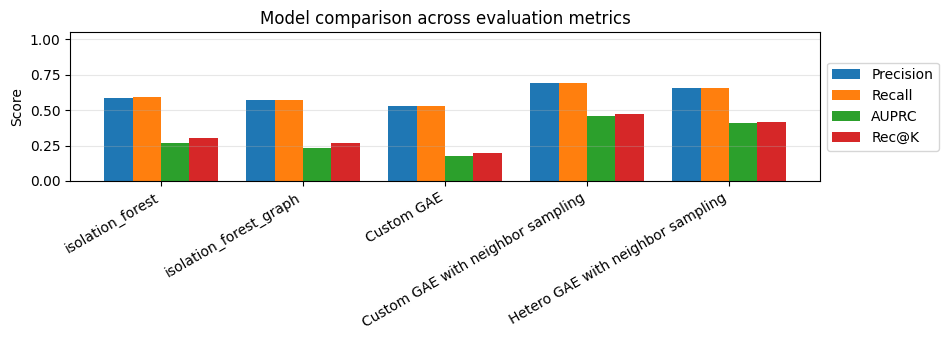

In [43]:
models_results = compare_models([
    isolation_forest_results,
    isolation_forest_graph_results,
    custom_gae_results,
    custom_gae_pinsage_results,
    hetero_gae_results,
])